# Fake News Detection on LIAR — BERT vs LLaMA 3.2 3B
## Final comparative analysis

This notebook consolidates every experiment run in the project into a single
comparison across four systems, evaluated on the **same** LIAR binary test split
(1,267 statements, 818 FAKE / 449 REAL):

| System | Type | Training on LIAR |
|---|---|---|
| **BERT baseline** | `bert-base-uncased`, fine-tuned, 3 epochs | yes |
| **BERT V2** | same, fine-tuned with class weights | yes |
| **LLaMA 3.2 3B zero-shot** | `meta-llama/llama-3.2-3b-instruct` via OpenRouter | no (prompting only) |
| **LLaMA 3.2 3B few-shot** | same model, 6 in-context examples (3 FAKE / 3 REAL) | no (prompting only) |

> **Terminology note.** The instruction-tuned model used through the API is
> *LLaMA 3.2 3B Instruct*, a 3-billion-parameter member of the Llama 3 model
> family. It is referred to as "LLaMA 3.2 3B" throughout; it is **not** the 8B
> or 70B Llama 3 model.

All per-sample predictions were produced by earlier scripts and are read here
from `results/`. The heavy lifting (alignment checks, metric computation, plots)
lives in `analysis/build_comparison.py`; this notebook loads its output and adds
interpretation.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 120

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
COMP = ROOT / "results" / "comparison"

MODELS = [
    "BERT baseline",
    "BERT V2",
    "LLaMA 3.2 3B zero-shot",
    "LLaMA 3.2 3B few-shot",
]
CLASSES = ["FAKE", "REAL"]
ORIGINAL_LABELS = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]
COLOURS = {
    "BERT baseline": "#4C72B0",
    "BERT V2": "#55A868",
    "LLaMA 3.2 3B zero-shot": "#C44E52",
    "LLaMA 3.2 3B few-shot": "#8172B2",
}
MAJORITY_ACC = 818 / 1267
print("Comparison artifacts:", COMP)
assert COMP.exists(), "run analysis/build_comparison.py first"

Comparison artifacts: C:\Users\Admin\Documents\Tema\FakeNewsDetection\results\comparison


## 1. Load and validate the merged predictions

In [2]:
merged = pd.read_csv(COMP / "predictions_merged.csv")
print("rows:", len(merged))
print(merged["true_binary"].value_counts())

# integrity checks
assert len(merged) == 1267
assert merged["true_binary"].value_counts().to_dict() == {"FAKE": 818, "REAL": 449}
for m in MODELS:
    assert merged[f"pred__{m}"].isin(CLASSES).all(), f"{m} has non FAKE/REAL predictions"
assert (
    merged["original_label"].map(
        {"pants-fire": "FAKE", "false": "FAKE", "barely-true": "FAKE",
         "half-true": "FAKE", "mostly-true": "REAL", "true": "REAL"}
    ) == merged["true_binary"]
).all(), "binary mapping mismatch"
print("\nAll alignment checks passed.")
merged.head(3)

rows: 1267
true_binary
FAKE    818
REAL    449
Name: count, dtype: int64

All alignment checks passed.


,idx,statement,original_label,true_binary,token_length,prob_fake__BERT baseline,prob_real__BERT baseline,conf__BERT baseline,pred__BERT baseline,prob_fake__BERT V2,prob_real__BERT V2,conf__BERT V2,pred__BERT V2,raw__LLaMA 3.2 3B zero-shot,conf__LLaMA 3.2 3B zero-shot,pred__LLaMA 3.2 3B zero-shot,raw__LLaMA 3.2 3B few-shot,conf__LLaMA 3.2 3B few-shot,pred__LLaMA 3.2 3B few-shot
0,0,Building a wall on the U.S.-Mexico border will...,true,REAL,19,0.949950,0.050050,0.949950,FAKE,0.613804,0.386196,0.613804,FAKE,REAL,NaN,REAL,REAL,NaN,REAL
1,1,Wisconsin is on pace to double the number of l...,false,FAKE,16,0.198076,0.801924,0.801924,REAL,0.245966,0.754034,0.754034,REAL,FAKE,NaN,FAKE,REAL,NaN,REAL
2,2,Says John McCain has done nothing to help the ...,false,FAKE,14,0.816723,0.183277,0.816723,FAKE,0.545933,0.454067,0.545933,FAKE,FAKE,NaN,FAKE,REAL,NaN,REAL


### Binary mapping actually used

The six LIAR truthfulness levels are collapsed as follows (verified above against
`test.csv`):

| binary target | original LIAR labels |
|---|---|
| **FAKE** | `pants-fire`, `false`, `barely-true`, **`half-true`** |
| **REAL** | `mostly-true`, `true` |

`half-true` sits on the **FAKE** side. This is the split the models were trained
and evaluated on, and every number below follows it.

## 2. Overall metrics

In [3]:
overall = pd.read_csv(COMP / "metrics_overall.csv").set_index("model").loc[MODELS]
display(overall.round(4))
print(f"Majority-class baseline (always FAKE): accuracy = {MAJORITY_ACC:.4f}")

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,mcc
model,,,,,,,,,
BERT baseline,0.6464,0.6167,0.6153,0.6167,0.6159,0.6486,0.6464,0.6474,0.2320
BERT V2,0.6298,0.6319,0.6212,0.6319,0.6179,0.6614,0.6298,0.6376,0.2529
LLaMA 3.2 3B zero-shot,0.4617,0.5625,0.6004,0.5625,0.4432,0.6620,0.4617,0.4136,0.1585
LLaMA 3.2 3B few-shot,0.3583,0.5026,0.6063,0.5026,0.2694,0.6794,0.3583,0.1952,0.0330


Majority-class baseline (always FAKE): accuracy = 0.6456


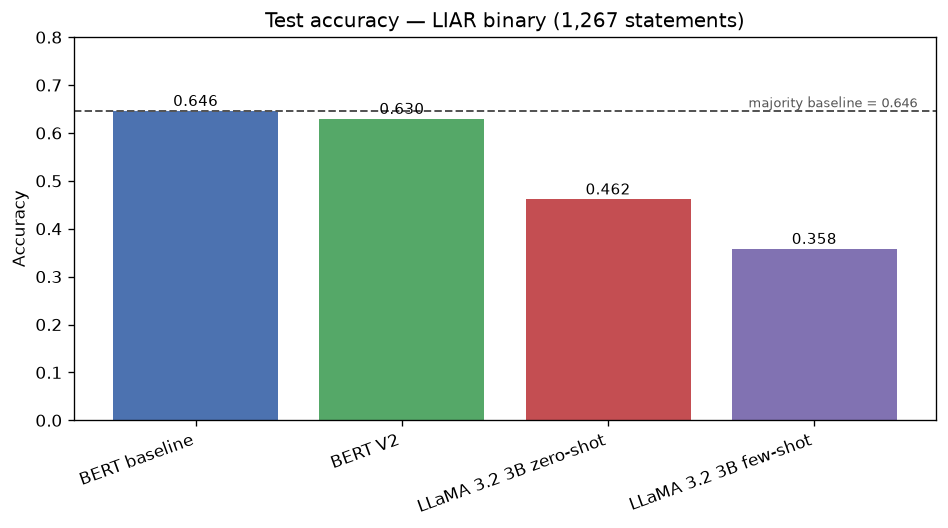

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(len(MODELS)), overall["accuracy"], color=[COLOURS[m] for m in MODELS])
ax.axhline(MAJORITY_ACC, ls="--", color="#555", lw=1.2)
ax.text(len(MODELS) - 0.5, MAJORITY_ACC + 0.008,
        f"majority baseline = {MAJORITY_ACC:.3f}", ha="right", fontsize=8, color="#555")
for i, v in enumerate(overall["accuracy"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS, rotation=20, ha="right")
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 0.8)
ax.set_title("Test accuracy — LIAR binary (1,267 statements)")
plt.tight_layout(); plt.show()

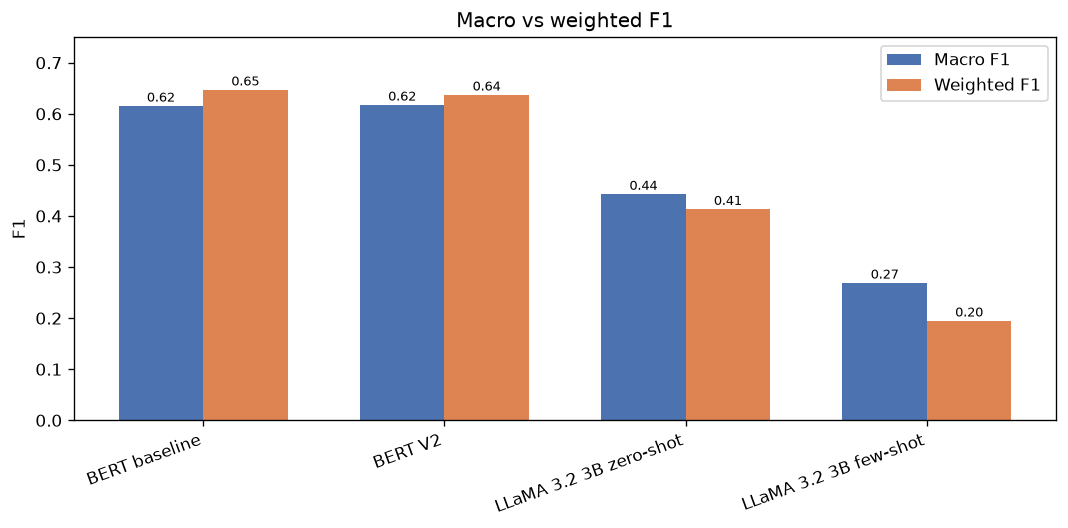

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(MODELS)); w = 0.35
ax.bar(x - w/2, overall["f1_macro"], w, label="Macro F1", color="#4C72B0")
ax.bar(x + w/2, overall["f1_weighted"], w, label="Weighted F1", color="#DD8452")
for xi, v in zip(x - w/2, overall["f1_macro"]):
    ax.text(xi, v + 0.008, f"{v:.2f}", ha="center", fontsize=8)
for xi, v in zip(x + w/2, overall["f1_weighted"]):
    ax.text(xi, v + 0.008, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=20, ha="right")
ax.set_ylabel("F1"); ax.set_ylim(0, 0.75); ax.legend()
ax.set_title("Macro vs weighted F1")
plt.tight_layout(); plt.show()

**Reading the table.**

* Neither BERT model beats the majority-class baseline on raw **accuracy**
  (0.6456). BERT baseline is level with it (0.6464); BERT V2 is just below
  (0.6298). Accuracy alone is therefore *not* an informative metric on this
  split — it rewards always saying FAKE.
* On metrics that account for both classes — **macro F1**, **balanced
  accuracy**, **MCC** — BERT V2 is the strongest system (MCC 0.253, balanced
  accuracy 0.632), narrowly ahead of BERT baseline (MCC 0.232).
* Both LLaMA configurations are far below every BERT metric: zero-shot
  MCC 0.159, few-shot MCC 0.033 (essentially chance-level association).
* The **weighted** F1 column flatters LLaMA (0.41 / 0.20) less than macro F1
  does, but only because weighted F1 is dominated by the majority class that
  LLaMA almost never predicts — it should not be read as "LLaMA is close".

## 3. Per-class performance (FAKE vs REAL)

In [6]:
per_class = pd.read_csv(COMP / "metrics_per_class.csv")
pivot = per_class.pivot_table(index="model", columns="class", values=["precision", "recall", "f1"])
pivot = pivot.reorder_levels([1, 0], axis=1).sort_index(axis=1).loc[MODELS]
display(pivot.round(4))

class                     FAKE                      REAL                  
                            f1 precision  recall      f1 precision  recall
model                                                                     
BERT baseline           0.7241    0.7295  0.7188  0.5077    0.5011  0.5145
BERT V2                 0.6854    0.7593  0.6247  0.5503    0.4832  0.6392
LLaMA 3.2 3B zero-shot  0.3417    0.8119  0.2164  0.5447    0.3889  0.9087
LLaMA 3.2 3B few-shot   0.0145    0.8571  0.0073  0.5243    0.3556  0.9978

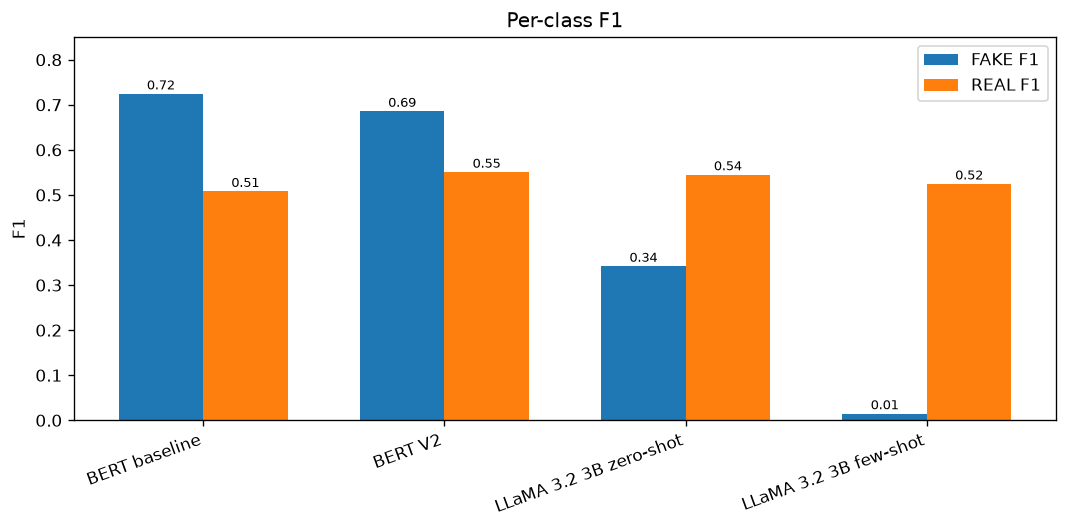

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(MODELS)); w = 0.35
for j, cls in enumerate(CLASSES):
    vals = [per_class[(per_class.model == m) & (per_class["class"] == cls)]["f1"].iloc[0] for m in MODELS]
    ax.bar(x + (j - 0.5) * w, vals, w, label=f"{cls} F1")
    for xi, v in zip(x + (j - 0.5) * w, vals):
        ax.text(xi, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=20, ha="right")
ax.set_ylabel("F1"); ax.set_ylim(0, 0.85); ax.legend()
ax.set_title("Per-class F1")
plt.tight_layout(); plt.show()

* **BERT baseline** is the only system with a genuinely usable FAKE detector
  (F1 0.72). Its REAL F1 (0.51) is weak — REAL recall 0.51.
* **BERT V2** trades FAKE performance (F1 0.72 → 0.69) for REAL performance
  (F1 0.51 → 0.55). The class weights did exactly what they were meant to:
  push REAL recall up (0.51 → 0.64) at the cost of FAKE recall (0.72 → 0.62).
* **LLaMA zero-shot** inverts the picture: FAKE recall collapses to 0.22 while
  REAL recall is 0.91. Its FAKE *precision* is high (0.81) only because it says
  FAKE so rarely.
* **LLaMA few-shot** degenerates almost entirely: FAKE recall 0.007 (6 of 818),
  REAL recall 0.998. It is a constant "REAL" classifier for practical purposes.

## 4. Confusion matrices

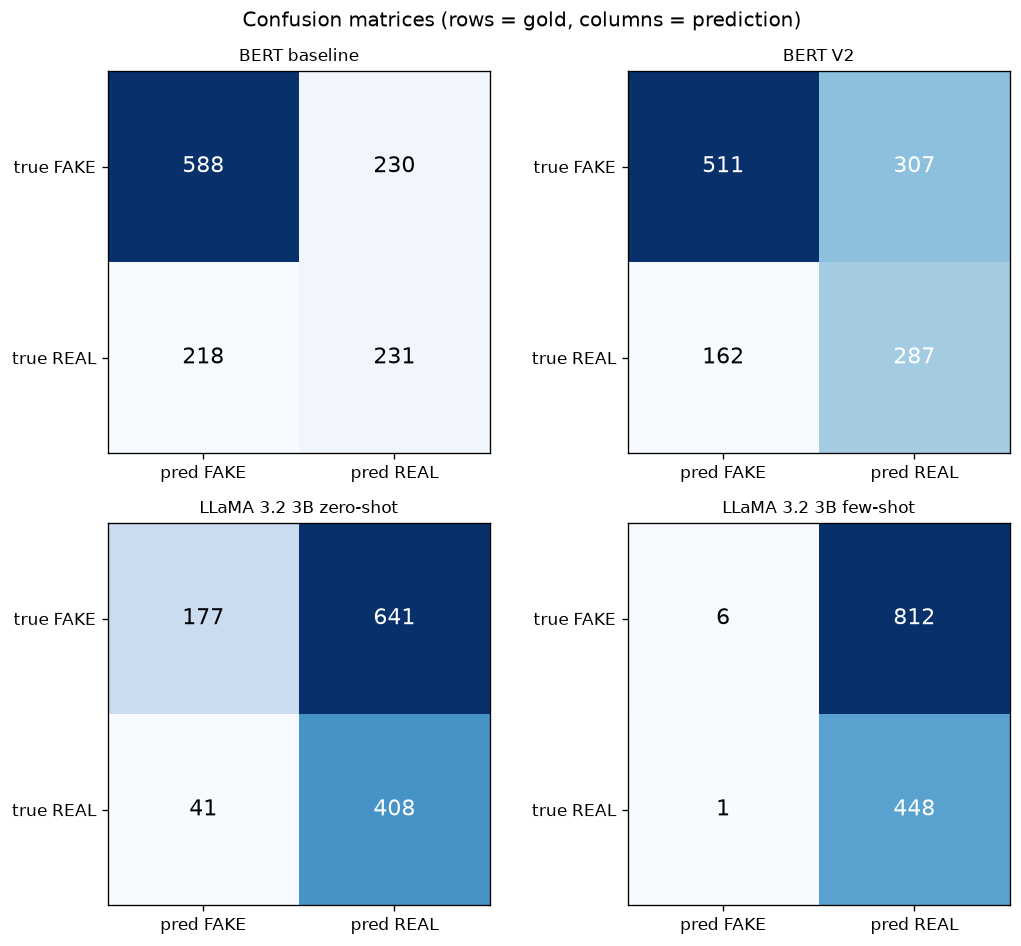

,true_FAKE_pred_FAKE,true_FAKE_pred_REAL,true_REAL_pred_FAKE,true_REAL_pred_REAL
model,,,,
BERT baseline,588,230,218,231
BERT V2,511,307,162,287
LLaMA 3.2 3B zero-shot,177,641,41,408
LLaMA 3.2 3B few-shot,6,812,1,448


In [8]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, m in zip(axes.ravel(), MODELS):
    cm = confusion_matrix(merged["true_binary"], merged[f"pred__{m}"], labels=CLASSES)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(m, fontsize=10)
    ax.set_xticks([0, 1], labels=[f"pred {c}" for c in CLASSES])
    ax.set_yticks([0, 1], labels=[f"true {c}" for c in CLASSES])
    thr = cm.max() / 2
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha="center", va="center",
                    color="white" if cm[r, c] > thr else "black", fontsize=13)
fig.suptitle("Confusion matrices (rows = gold, columns = prediction)")
plt.tight_layout(); plt.show()

pd.read_csv(COMP / "confusion_matrices.csv").set_index("model").loc[MODELS]

## 5. Error analysis — direction of mistakes

,fake_to_real,real_to_fake,total_errors,error_rate
model,,,,
BERT baseline,230,218,448,0.353591
BERT V2,307,162,469,0.370166
LLaMA 3.2 3B zero-shot,641,41,682,0.538279
LLaMA 3.2 3B few-shot,812,1,813,0.641673


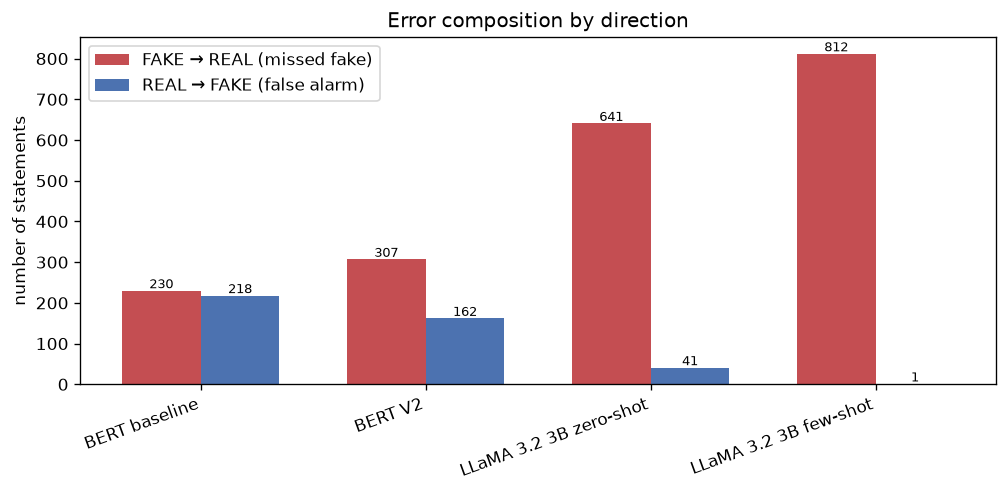

In [9]:
err = pd.read_csv(COMP / "error_directions.csv").set_index("model").loc[MODELS]
display(err)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(MODELS)); w = 0.35
ax.bar(x - w/2, err["fake_to_real"], w, label="FAKE → REAL (missed fake)", color="#C44E52")
ax.bar(x + w/2, err["real_to_fake"], w, label="REAL → FAKE (false alarm)", color="#4C72B0")
for xi, v in zip(x - w/2, err["fake_to_real"]):
    ax.text(xi, v + 6, int(v), ha="center", fontsize=8)
for xi, v in zip(x + w/2, err["real_to_fake"]):
    ax.text(xi, v + 6, int(v), ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=20, ha="right")
ax.set_ylabel("number of statements"); ax.legend()
ax.set_title("Error composition by direction")
plt.tight_layout(); plt.show()

* **BERT baseline** errors are almost symmetric (230 vs 218): no strong class
  bias, just limited discriminative power.
* **BERT V2** shifts toward FAKE → REAL errors (307 vs 162): consistent with the
  class-weight nudge toward predicting REAL.
* **LLaMA zero-shot** errors are 94% "missed fakes" (641 FAKE → REAL vs 41
  REAL → FAKE). As a fake-news *filter* this is the worst possible failure mode:
  it lets almost every false statement through.
* **LLaMA few-shot** is a constant-REAL classifier — 812 missed fakes, 1 false
  alarm.

## 6. Performance by original LIAR truthfulness level

In [10]:
by_lab = pd.read_csv(COMP / "performance_by_original_label.csv")
acc_lab = by_lab.pivot(index="original_label", columns="model", values="accuracy").loc[ORIGINAL_LABELS, MODELS]
display(acc_lab.round(4))
display(by_lab[by_lab.model == "BERT baseline"].set_index("original_label")[["samples", "correct", "incorrect"]].loc[ORIGINAL_LABELS])

model,BERT baseline,BERT V2,LLaMA 3.2 3B zero-shot,LLaMA 3.2 3B few-shot
original_label,,,,
pants-fire,0.8370,0.7935,0.3804,0.0326
false,0.7269,0.5984,0.1968,0.0080
barely-true,0.7783,0.6840,0.2170,0.0047
half-true,0.6226,0.5434,0.1774,0.0000
mostly-true,0.4730,0.6183,0.9087,1.0000
true,0.5625,0.6635,0.9087,0.9952


,samples,correct,incorrect
original_label,,,
pants-fire,92,77,15
false,249,181,68
barely-true,212,165,47
half-true,265,165,100
mostly-true,241,114,127
true,208,117,91


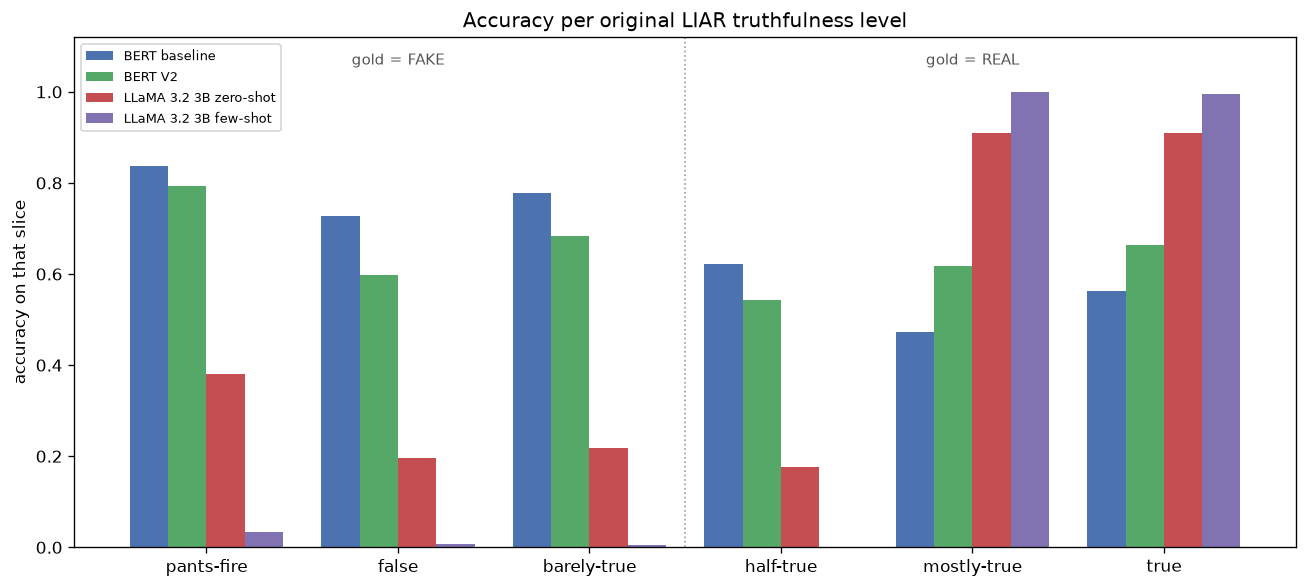

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ORIGINAL_LABELS)); w = 0.2
for k, m in enumerate(MODELS):
    ax.bar(x + (k - 1.5) * w, acc_lab[m].values, w, label=m, color=COLOURS[m])
ax.axvline(2.5, color="#999", lw=1, ls=":")
bbox = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85)
ax.text(1.0, 1.06, "gold = FAKE", ha="center", fontsize=9, color="#555", bbox=bbox)
ax.text(4.0, 1.06, "gold = REAL", ha="center", fontsize=9, color="#555", bbox=bbox)
ax.set_xticks(x); ax.set_xticklabels(ORIGINAL_LABELS)
ax.set_ylabel("accuracy on that slice"); ax.set_ylim(0, 1.12); ax.legend(fontsize=8)
ax.set_title("Accuracy per original LIAR truthfulness level")
plt.tight_layout(); plt.show()

This is the most diagnostic view in the whole study.

* **BERT baseline** has a clean monotonic gradient: it is best on the most
  clearly false statements (`pants-fire` 0.84, `barely-true` 0.78, `false`
  0.73) and worst on statements near the truth boundary (`half-true` 0.62,
  `mostly-true` 0.47, `true` 0.56). It has essentially learned "how false does
  this sound".
* **BERT V2** flattens that gradient — it gives up ~13 pp on `false` /
  `barely-true` and gains ~9–15 pp on `mostly-true` / `true`. Range across the
  six levels shrinks from 0.47–0.84 (baseline) to 0.54–0.79 (V2).
* **LLaMA zero-shot** is close to a mirror image: ~0.18–0.38 on the FAKE
  levels, 0.91 on both REAL levels. It only shows FAKE signal on `pants-fire`
  (0.38).
* **LLaMA few-shot** is degenerate: ~0.00–0.03 on every FAKE level, ~1.00 on
  every REAL level.

**Hardest levels overall:** `half-true`, `mostly-true`, `true` — the region
where human annotators themselves disagree most. Every system except the
degenerate few-shot run loses accuracy as the statement gets closer to "true".

## 7. Accuracy by statement length (BERT-tokenizer tokens)

In [12]:
by_len = pd.read_csv(COMP / "accuracy_by_token_length.csv")
order = ["1-16", "17-32", "33-64", "65-128", "129+"]
display(by_len.pivot(index="length_bucket", columns="model", values="accuracy").reindex(order)[MODELS].round(4))
display(by_len[by_len.model == "BERT baseline"].set_index("length_bucket").reindex(order)[["samples"]])

model,BERT baseline,BERT V2,LLaMA 3.2 3B zero-shot,LLaMA 3.2 3B few-shot
length_bucket,,,,
1-16,0.6716,0.6530,0.4590,0.3097
17-32,0.6601,0.6377,0.4480,0.3570
33-64,0.5781,0.5781,0.5105,0.4177
65-128,0.3333,0.6667,0.3333,0.3333
129+,NaN,NaN,NaN,NaN


,samples
length_bucket,
1-16,268
17-32,759
33-64,237
65-128,3
129+,0


Statements are short (median 22 tokens; 95th percentile 42). The `65–128`
bucket has only 3 samples, so it is noise. Within the meaningful buckets both
BERT models lose ~8–9 pp going from ≤32 tokens to 33–64 tokens; the LLaMA runs
show no consistent length effect (their behaviour is driven by class bias, not
by how much text they get).

## 8. Confidence analysis

In [13]:
conf = pd.read_csv(COMP / "confidence_summary.csv").set_index("model").loc[MODELS]
display(conf)

,confidence_available,correct_mean,correct_median,incorrect_mean,incorrect_median,high_conf_errors_ge_0.90,high_conf_errors_ge_0.95
model,,,,,,,
BERT baseline,True,0.863702,0.913841,0.801404,0.825979,156.0,84.0
BERT V2,True,0.696849,0.703183,0.649435,0.642804,0.0,0.0
LLaMA 3.2 3B zero-shot,False,NaN,NaN,NaN,NaN,NaN,NaN
LLaMA 3.2 3B few-shot,False,NaN,NaN,NaN,NaN,NaN,NaN


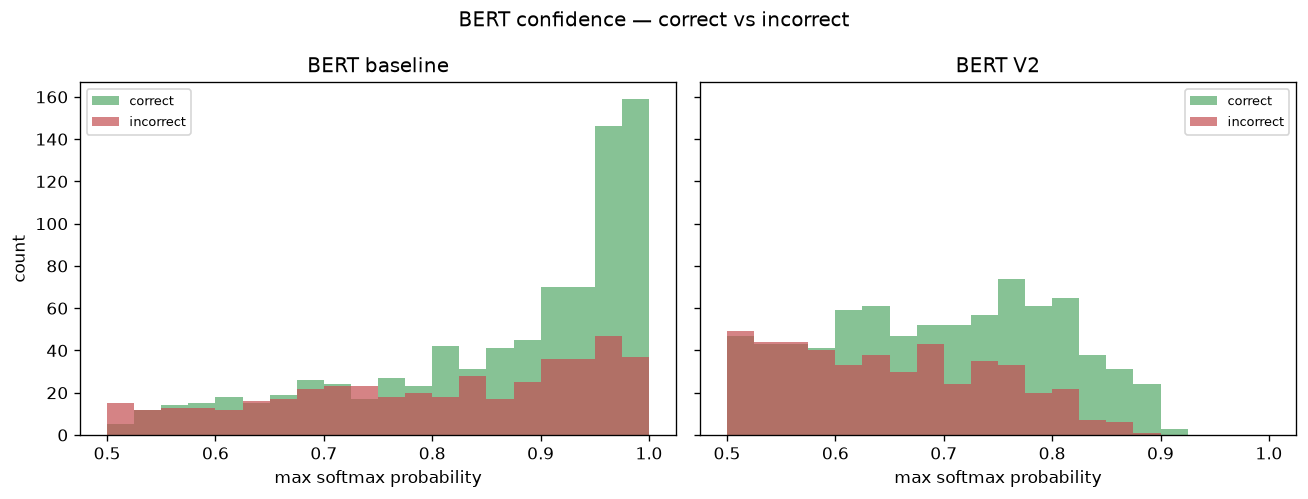

In [14]:
bert_models = [m for m in MODELS if m.startswith("BERT")]
fig, axes = plt.subplots(1, len(bert_models), figsize=(11, 4.2), sharey=True)
for ax, m in zip(np.atleast_1d(axes), bert_models):
    c = merged[f"conf__{m}"]
    ok = merged[f"pred__{m}"] == merged["true_binary"]
    ax.hist(c[ok], bins=20, range=(0.5, 1.0), alpha=0.7, label="correct", color="#55A868")
    ax.hist(c[~ok], bins=20, range=(0.5, 1.0), alpha=0.7, label="incorrect", color="#C44E52")
    ax.set_title(m); ax.set_xlabel("max softmax probability"); ax.legend(fontsize=8)
axes[0].set_ylabel("count")
fig.suptitle("BERT confidence — correct vs incorrect")
plt.tight_layout(); plt.show()

**BERT baseline is badly calibrated / over-confident.** Mean confidence on
*wrong* predictions is 0.80; it makes **156** errors at ≥ 0.90 confidence and
**84** at ≥ 0.95. A high softmax score from this model is not a reliable signal
that the answer is right.

**BERT V2 is much less over-confident.** Confidence is compressed toward 0.65–0.70
for both correct and incorrect predictions, and there are **zero** errors above
0.90. The class-weighted loss both re-balanced the classes and softened the
output distribution. The gap between correct-mean (0.70) and incorrect-mean
(0.65) is small but in the right direction.

**LLaMA:** no confidence signal is available. The OpenRouter providers serving
`meta-llama/llama-3.2-3b-instruct` (Parasail, Cloudflare) do not return usable
token log-probabilities for the label token, and the runs used
`temperature = 0`, so there is no sampling distribution to estimate from either.
LLaMA confidence is therefore out of scope; the strong, systematic class bias
documented above is the relevant reliability finding for the LLaMA systems.

## 9. Zero-shot vs few-shot (LLaMA)

In [15]:
zs, fs = "LLaMA 3.2 3B zero-shot", "LLaMA 3.2 3B few-shot"
comp = pd.concat([overall.loc[[zs, fs], ["accuracy", "balanced_accuracy", "f1_macro", "mcc"]]], axis=0)
display(comp.round(4))

dist = pd.DataFrame({
    "zero-shot": merged[f"pred__{zs}"].value_counts(),
    "few-shot": merged[f"pred__{fs}"].value_counts(),
}).reindex(CLASSES)
dist["gold"] = merged["true_binary"].value_counts().reindex(CLASSES)
display(dist)

,accuracy,balanced_accuracy,f1_macro,mcc
model,,,,
LLaMA 3.2 3B zero-shot,0.4617,0.5625,0.4432,0.1585
LLaMA 3.2 3B few-shot,0.3583,0.5026,0.2694,0.0330


,zero-shot,few-shot,gold
FAKE,218,7,818
REAL,1049,1260,449


Few-shot prompting **hurt** this model on this task:

| | zero-shot | few-shot |
|---|---|---|
| accuracy | 0.462 | 0.358 |
| macro F1 | 0.443 | 0.269 |
| MCC | 0.159 | 0.033 |
| predicts REAL | 1,049 / 1,267 | **1,260 / 1,267** |

The six demonstrations were class-balanced (3 FAKE / 3 REAL), so this is **not**
majority-label bias from the demo set. The most likely drivers, all documented
in the in-context-learning literature:

* **Recency / proximity bias** (Zhao et al., 2021; Lu et al., 2022): the last
  demonstration and the trailing instruction both end on the token `REAL`, and
  the model over-weights what it saw most recently.
* **Weak model, brittle format** (Min et al., 2022): a 3B instruction model
  follows surface prompt structure more than demonstration semantics; the
  `Statement: … / Label: …` block format plus the extra "Return exactly one word"
  footer pushed it to a single dominant output.
* **No verifiability signal**: LIAR statements cannot be fact-checked from the
  sentence alone, so demonstrations add little usable pattern for a model with
  no retrieval and no world grounding for these specific claims.

**Takeaway for the thesis:** naïve few-shot prompting is not a free improvement;
without prompt calibration / careful demonstration design it can collapse a
small instruction model onto one class.

## 10. Statistical significance (pairwise McNemar)

In [16]:
mcn = pd.read_csv(COMP / "mcnemar_tests.csv")
display(mcn.round(4))

,model_a,model_b,a_correct_b_wrong,a_wrong_b_correct,mcnemar_chi2_cc,p_value,significant_0.05,cohen_kappa_predictions
0,BERT baseline,BERT V2,137,116,1.5810,0.2086,False,0.5937
1,BERT baseline,LLaMA 3.2 3B zero-shot,462,228,78.6797,0.0000,True,0.0759
2,BERT baseline,LLaMA 3.2 3B few-shot,583,218,165.4132,0.0000,True,0.0038
3,BERT V2,LLaMA 3.2 3B zero-shot,395,182,77.8925,0.0000,True,0.1250
4,BERT V2,LLaMA 3.2 3B few-shot,505,161,176.6502,0.0000,True,0.0098
5,LLaMA 3.2 3B zero-shot,LLaMA 3.2 3B few-shot,171,40,80.0948,0.0000,True,0.0521


* **BERT baseline vs BERT V2:** χ²(cc) = 1.58, **p = 0.21** → the accuracy
  difference between the two BERT models is **not statistically significant** on
  this test set. The honest statement is "V2 rebalances the error profile", not
  "V2 is worse" (or better) on overall correctness. Their predictions agree on
  1,014 / 1,267 items (Cohen's κ = 0.59).
* **Every BERT vs LLaMA pair:** p < 10⁻¹⁵ → BERT is significantly more accurate
  than either LLaMA configuration, by a wide margin.
* **LLaMA zero-shot vs few-shot:** p < 10⁻¹⁵ → the few-shot degradation is
  significant, not noise.
* BERT and LLaMA predictions are almost uncorrelated (κ ≈ 0.08–0.13): they are
  not "the same model a bit worse", they are solving the task in different ways.

## 11. Interpretation — answers to the study questions

**Which model performs best, and on which metric?**
BERT (fine-tuned) clearly beats LLaMA 3.2 3B (prompted) on every metric.
Between the two BERT variants: **BERT baseline** is marginally ahead on raw
accuracy and FAKE F1, **BERT V2** is ahead on macro F1, balanced accuracy, MCC
and REAL F1 — and the accuracy gap between them is not statistically significant
(McNemar p = 0.21). For a fake-news filter, where catching FAKE matters, BERT
baseline's FAKE recall (0.72 vs 0.62) is the more relevant number; for a
balanced two-class report, V2 is preferable.

**Why does fine-tuned BERT win?**
It has seen 10,220 labelled LIAR statements and adapted its representation to
the LIAR annotation style (which rewards recognising rhetorical markers of
falsehood). The prompted LLaMA has task instructions but no exposure to this
label distribution or annotation convention, and no fact-checking evidence.

**Which model is most balanced?**
BERT V2 (balanced accuracy 0.632, near-equal per-class recall 0.62 / 0.64).
BERT baseline is moderately FAKE-leaning; both LLaMA runs are severely
REAL-leaning.

**Which model handles FAKE best / worst?**
Best: BERT baseline (FAKE recall 0.72). Worst: LLaMA few-shot (FAKE recall
0.007) — it essentially never flags a false statement.

**Does prompting strategy matter for LLaMA?**
Yes, and here it made things worse: zero-shot → few-shot dropped accuracy
0.462 → 0.358 and macro F1 0.443 → 0.269 (significant). Few-shot is not a
guaranteed improvement for a small instruction model on a non-verifiable task.

**Does fine-tuning matter for BERT?**
Yes for behaviour shape, not for headline accuracy: class-weighted fine-tuning
(V2) moved REAL recall 0.51 → 0.64 and removed all ≥ 0.90-confidence errors,
while leaving overall accuracy statistically unchanged.

**Which LIAR levels are hardest?**
`half-true`, `mostly-true`, `true` — the truth-boundary region. BERT baseline
falls from 0.84 (`pants-fire`) to 0.47 (`mostly-true`); LLaMA is near-random or
worse on the FAKE levels. This mirrors the low human agreement on these
categories in the original LIAR dataset.

**Are the models over-confident?**
BERT baseline: strongly (156 errors at ≥ 0.90 confidence). BERT V2: no
(0 errors ≥ 0.90). LLaMA: no usable confidence signal, but a rigid, systematic
class bias — which is its own form of unreliable behaviour.

**Advantages / limitations of each approach**

*Fine-tuned BERT* — + best accuracy and FAKE recall on LIAR; + runs locally on
CPU; − needs labelled data; − baseline is over-confident; − ceiling ≈ 0.65
accuracy on this hard benchmark.

*Prompted LLaMA 3.2 3B* — + no training or labels needed; + trivial to deploy
via API; − below the majority-class baseline here; − severe REAL bias; − few-shot
made it worse; − no confidence signal from the provider; − 3B instruction model
is too small for reliable stance/veracity judgement on short, non-verifiable
political claims.

## 12. Conclusions

1. On the LIAR binary task, **a fine-tuned `bert-base-uncased` clearly
   outperforms a prompted LLaMA 3.2 3B Instruct model**, zero-shot or few-shot,
   and the difference is statistically significant.
2. **Accuracy is the wrong headline metric on this split** (majority baseline
   0.646). Macro F1, balanced accuracy, MCC and the per-class / per-LIAR-level
   breakdowns are what separate the systems.
3. **Class-weighted fine-tuning (BERT V2)** does not change overall accuracy
   significantly but produces a materially better-behaved model: balanced
   per-class recall and far better calibration.
4. **Few-shot prompting is not a free lunch.** With balanced but naively
   formatted demonstrations, LLaMA 3.2 3B collapsed almost entirely onto the
   REAL class (1,260 / 1,267), consistent with known recency / format
   sensitivity of in-context learning in small models.
5. **The truth-boundary LIAR levels (`half-true` … `true`) are hard for every
   approach**, reflecting genuine label subjectivity rather than a single
   model's weakness.
6. **Reliability differs by approach:** BERT baseline is accurate but
   over-confident; BERT V2 is calibrated; the LLaMA runs are miscalibrated in
   the structural sense that they answer with a near-fixed class prior.

### Threats to validity
* Single test split, single random seed per model; no cross-validation.
* LLaMA evaluated only at 3B and only via one API provider; larger Llama 3
  models are expected to do better and are **not** covered by these conclusions.
* LLaMA confidence could not be measured (provider limitation), so the
  calibration comparison is BERT-only.
* Prompt wording was not tuned; a calibrated or better-formatted prompt could
  change the LLaMA numbers.

### Reference points from the literature
* LIAR is a deliberately hard benchmark: the original paper (Wang, 2017) reports
  ~0.20–0.27 accuracy on the six-way task; published binary results typically
  land in the low-to-mid 0.60s, i.e. close to what BERT achieves here.
* BERT over-confidence on classification is documented (Desai & Durrett, 2020;
  Guo et al., 2017).
* In-context-learning instability — order, recency and format sensitivity, and
  the limited role of demonstration *labels* — is documented in Zhao et al.
  (2021), Lu et al. (2022) and Min et al. (2022).
* Studies of LLMs as zero-shot misinformation detectors generally find that
  small/medium prompted LLMs trail task-specific fine-tuned encoders on
  benchmark data (e.g. Hu et al., 2024; Pelrine et al., 2023) — consistent with
  the gap seen here.

*(Bibliographic details should be verified against the manuscript's reference
list before submission.)*